# OULAD Baseline ML Pipeline Project



## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_score, recall_score, balanced_accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

## 2. Load Data

In [2]:
path = r"C:\Users\rq0016\Documents\Personal 2024-2025\phd student success\New_approach\Coding\Data"

student_info = pd.read_csv(f'{path}/studentInfo.csv')
student_vle = pd.read_csv(f'{path}/studentVle.csv')
student_assess = pd.read_csv(f'{path}/studentAssessment.csv')
assessments = pd.read_csv(f'{path}/assessments.csv')

## 3. Risk Label Definition


In [3]:
# Binary risk:
# 1 = success (Pass/Distinction)
# 0 = at-risk (Fail/Withdrawn)

student_info['target'] = student_info['final_result'].apply(
    lambda x: 1 if x in ['Pass', 'Distinction'] else 0
)

print(student_info['target'].value_counts())

target
0    17208
1    15385
Name: count, dtype: int64


## 4. Temporal Filtering (Leakage-Safe)

In [4]:
def filter_window(vle, assess, window):
    vle_w = vle[vle['date'] <= window]
    assess = assess.merge(assessments[['id_assessment','code_module','code_presentation']], on='id_assessment', how='left')
    assess_w = assess[assess['date_submitted'] <= window]
    return vle_w, assess_w
print(filter_window(student_vle, student_assess, 30)[0].shape)

(2980575, 6)


## 5. Feature Engineering

In [5]:
def build_features(vle_w, assess_w):
    vle = vle_w.groupby(['id_student','code_module','code_presentation']).agg({'sum_click':['sum','mean','std']})
    vle.columns = ['vle_total','vle_mean','vle_std']
    vle = vle.reset_index()

    assess = assess_w.groupby(['id_student','code_module','code_presentation']).agg({'score':['mean','max'],'date_submitted':'count'})
    assess.columns = ['assess_mean','assess_max','assess_count']
    assess = assess.reset_index()

    df = vle.merge(assess, how='left', on=['id_student','code_module','code_presentation'])
    df = df.merge(student_info, on=['id_student','code_module','code_presentation'], how='left')
    df.fillna(0, inplace=True)
    return df
# Redefine with dtype-safe missing value handling
def build_features(vle_w, assess_w):
    vle = vle_w.groupby(['id_student', 'code_module', 'code_presentation']).agg({'sum_click': ['sum', 'mean', 'std']})
    vle.columns = ['vle_total', 'vle_mean', 'vle_std']
    vle = vle.reset_index()

    assess = assess_w.groupby(['id_student', 'code_module', 'code_presentation']).agg({'score': ['mean', 'max'], 'date_submitted': 'count'})
    assess.columns = ['assess_mean', 'assess_max', 'assess_count']
    assess = assess.reset_index()

    df = vle.merge(assess, how='left', on=['id_student', 'code_module', 'code_presentation'])
    df = df.merge(student_info, on=['id_student', 'code_module', 'code_presentation'], how='left')

    num_cols = df.select_dtypes(include=[np.number]).columns
    cat_cols = df.columns.difference(num_cols)

    df[num_cols] = df[num_cols].fillna(0)
    df[cat_cols] = df[cat_cols].fillna('Unknown')
    return df

print(build_features(*filter_window(student_vle, student_assess, 30)).shape)


(28842, 19)


## 6. Build datasets (weeks 2/4/6/8)

In [6]:
weeks=[2,4,6,8]
datasets={}
for w in weeks:
    vle_w, assess_w = filter_window(student_vle, student_assess, w*7)
    # Rebuild features here to avoid fillna(0) on string columns
    vle = (
        vle_w.groupby(['id_student', 'code_module', 'code_presentation'])
        .agg({'sum_click': ['sum', 'mean', 'std']})
    )
    vle.columns = ['vle_total', 'vle_mean', 'vle_std']
    vle = vle.reset_index()

    assess = (
        assess_w.groupby(['id_student', 'code_module', 'code_presentation'])
        .agg({'score': ['mean', 'max'], 'date_submitted': 'count'})
    )
    assess.columns = ['assess_mean', 'assess_max', 'assess_count']
    assess = assess.reset_index()

    df = vle.merge(
        assess, how='left', on=['id_student', 'code_module', 'code_presentation']
    ).merge(
        student_info, how='left', on=['id_student', 'code_module', 'code_presentation']
    )

    num_cols = df.select_dtypes(include=[np.number]).columns
    cat_cols = df.columns.difference(num_cols)

    df[num_cols] = df[num_cols].fillna(0)
    df[cat_cols] = df[cat_cols].fillna('Unknown')
    datasets[w]=df

print(datasets[2].shape)

(28081, 19)


## 7. Leakage Detection Tests

In [7]:
df = datasets[8]

# target leakage
print([c for c in df.columns if 'final' in c.lower()])

# correlation test
numeric = df.select_dtypes('number')
print(numeric.corr()['target'].sort_values(ascending=False).head(10))

['final_result']
target                  1.000000
assess_max              0.430440
assess_mean             0.426634
assess_count            0.317894
vle_total               0.273096
vle_mean                0.140285
vle_std                 0.079248
id_student              0.019430
num_of_prev_attempts   -0.108845
studied_credits        -0.113743
Name: target, dtype: float64


### Shuffle Leakage Test (only if I need to adjust )

In [8]:
def shuffle_test(X_train,y_train,X_test,y_test,model):
    y_shuf = y_train.sample(frac=1.0, random_state=42)
    model.fit(X_train,y_shuf)
    prob = model.predict_proba(X_test)[:,1]
    print('AUROC shuffled:', roc_auc_score(y_test, prob))

print('Original performance:')
X = df.drop(columns=['target','id_student','code_module','code_presentation','final_result'])
y = df['target']   
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
model = RandomForestClassifier(random_state=42)
# Encode categorical features so RandomForest can train/predict
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

# Ensure train/test have identical columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

model.fit(X_train, y_train)
prob = model.predict_proba(X_test)[:,1]
print('AUROC original:', roc_auc_score(y_test, prob))
shuffle_test(X_train, y_train, X_test, y_test, model)


Original performance:
AUROC original: 0.8235793565813323
AUROC shuffled: 0.5002893828617061


Correction workflow to know if I need to Shuffle

In [9]:
# original
def evaluate(model, X_test, y_test):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    return {
        "AUROC": roc_auc_score(y_test, y_prob),
        "AUPRC": average_precision_score(y_test, y_prob),
        "F1": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "Balanced_Accuracy": balanced_accuracy_score(y_test, y_pred),
    }

print("Original:")
model.fit(X_train, y_train)
print(evaluate(model, X_test, y_test))

# shuffled
y_shuffled = y_train.sample(frac=1.0, random_state=42)

model.fit(X_train, y_shuffled)
print("\nShuffled:")
print(evaluate(model, X_test, y_test))


Original:
{'AUROC': 0.8235793565813323, 'AUPRC': 0.805088773597286, 'F1': 0.77995979588681, 'Precision': 0.7411107846018219, 'Recall': 0.8231070496083551, 'Balanced_Accuracy': 0.7515462600021434}

Shuffled:
{'AUROC': 0.5002893828617061, 'AUPRC': 0.5237901468657699, 'F1': 0.5604294478527607, 'Precision': 0.5286458333333334, 'Recall': 0.5962793733681462, 'Balanced_Accuracy': 0.5022806238435356}


Leakeage detection visuallization

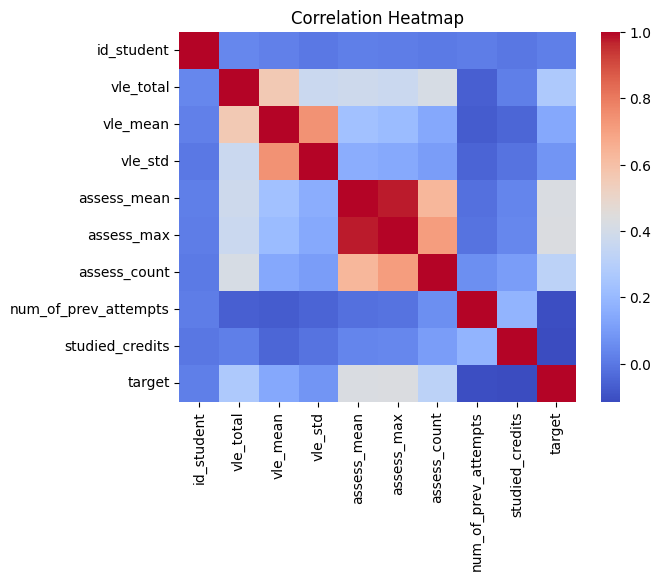

In [10]:
#Leak detection visualization
df=datasets[8]
corr=df.select_dtypes('number').corr()
sns.heatmap(corr,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Top feature importances

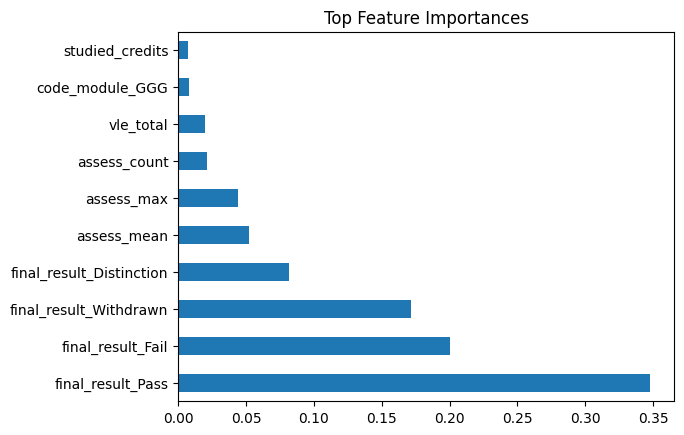

In [11]:
X=df.drop(columns=['target','id_student'])
y=df['target']
X=pd.get_dummies(X)
model=RandomForestClassifier()
model.fit(X,y)
imp=pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
imp.head(10).plot(kind='barh')
plt.title('Top Feature Importances')
plt.show()

## 8. Train/Test Split

In [12]:
def split(df):
    X = df.drop(columns=['target','id_student'])
    y = df['target']
    return train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

=== CLASS DISTRIBUTION (%) ===
         Original      Train       Test
target                                 
1       52.676822  52.677727  52.673199
0       47.323178  47.322273  47.326801

=== DISTRIBUTION DIFFERENCES (%) ===
         Original      Train       Test  Train-Original  Test-Original
target                                                                
1       52.676822  52.677727  52.673199        0.000906      -0.003622
0       47.323178  47.322273  47.326801       -0.000906       0.003622


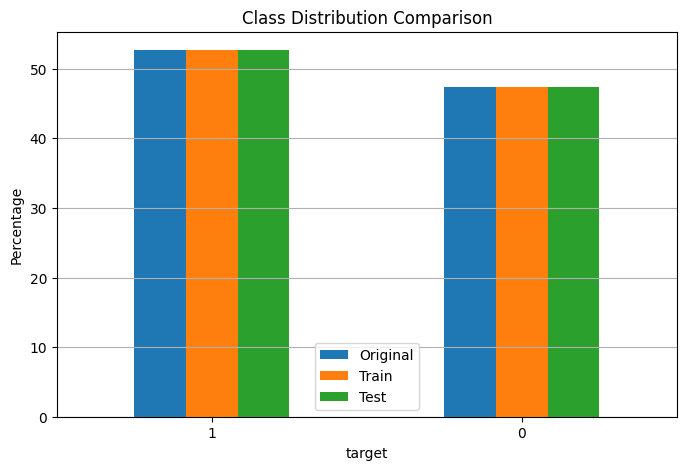

In [ ]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


def compare_distributions(df):

    # Split
    X = df.drop(columns=['target', 'id_student'])
    y = df['target']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    # Combined into dataframe for comparison
    dist_df = pd.DataFrame({
        'Original': y.value_counts(normalize=True),
        'Train': y_train.value_counts(normalize=True),
        'Test': y_test.value_counts(normalize=True)
    }) * 100

    print("=== CLASS DISTRIBUTION (%) ===")
    print(dist_df)

    # Difference table
    diff_df = dist_df.copy()
    diff_df['Train-Original'] = diff_df['Train'] - diff_df['Original']
    diff_df['Test-Original'] = diff_df['Test'] - diff_df['Original']

    print("\n=== DISTRIBUTION DIFFERENCES (%) ===")
    print(diff_df)

    # Visualization
    dist_df.plot(kind='bar', figsize=(8,5))
    plt.title("Class Distribution Comparison")
    plt.ylabel("Percentage")
    plt.xticks(rotation=0)
    plt.grid(axis='y')
    plt.show()

    return dist_df, diff_df
dist_df, diff_df = compare_distributions(datasets[8])

## 9. Underfitting Diagnostics

In [14]:
# Accept either a single dataframe or a dictionary like {week: dataframe}
def diagnose_underfitting_oulad(df):
    # Accept either a single dataframe or a dictionary like {week: dataframe}
    if isinstance(df, dict):
        for w, df_w in df.items():
            print(f"\n===== WEEK {w} =====")
            diagnose_underfitting_oulad(df_w)
        return

    print("=== OULAD UNDERFITTING DIAGNOSTICS ===\n")

    # 1. Class balance
    print("1. Class balance:")
    print(df['target'].value_counts(normalize=True))
    print()

    # 2. Feature matrix
    X = df.drop(columns=['target', 'id_student'], errors='ignore')
    X = pd.get_dummies(X)

    # 3. Sparsity
    print("2. Feature sparsity (top 10):")
    sparsity = (X == 0).mean().sort_values(ascending=False)
    print(sparsity.head(10))
    print()

    # 4. Variance
    print("3. Feature variance (lowest 10):")
    variance = X.var().sort_values()
    print(variance.head(10))
    print()

    # 5. Samples vs features
    print("4. Shape:")
    print("Samples:", X.shape[0])
    print("Features:", X.shape[1])
    print()

    # 6. Constant features
    const_cols = [c for c in X.columns if X[c].nunique() <= 1]
    print(f"5. Constant features: {len(const_cols)}")

    # 7. OULAD-specific: activity signal
    vle_cols = [c for c in X.columns if 'vle_' in c]
    if vle_cols:
        print("\n6. Average activity signal:")
        print(X[vle_cols].mean().sort_values().head())

    print("\n=== END ===")

print("=== OULAD UNDERFITTING DIAGNOSTICS ===\n")

# 1. Class balance
print("1. Class balance:")
print(df['target'].value_counts(normalize=True))
print()

# 2. Feature matrix
X = df.drop(columns=['target', 'id_student'], errors='ignore')
X = pd.get_dummies(X)

# 3. Sparsity
print("2. Feature sparsity (top 10):")
sparsity = (X == 0).mean().sort_values(ascending=False)
print(sparsity.head(10))
print()

# 4. Variance
print("3. Feature variance (lowest 10):")
variance = X.var().sort_values()
print(variance.head(10))
print()

# 5. Samples vs features
print("4. Shape:")
print("Samples:", X.shape[0])
print("Features:", X.shape[1])
print()

# 6. Constant features
const_cols = [c for c in X.columns if X[c].nunique() <= 1]
print(f"5. Constant features: {len(const_cols)}")

# 7. OULAD-specific: activity signal
vle_cols = [c for c in X.columns if 'vle_' in c]
if vle_cols:
    print("\n6. Average activity signal:")
    print(X[vle_cols].mean().sort_values().head())

print("\n=== END ===")


=== OULAD UNDERFITTING DIAGNOSTICS ===

1. Class balance:
target
1    0.526768
0    0.473232
Name: proportion, dtype: float64

2. Feature sparsity (top 10):
age_band_55<=                                    0.992951
highest_education_No Formal quals                0.990029
highest_education_Post Graduate Qualification    0.989616
code_module_AAA                                  0.974728
imd_band_Unknown                                 0.963896
region_Ireland                                   0.961833
region_North Region                              0.943885
region_Yorkshire Region                          0.939243
region_South East Region                         0.935014
region_Wales                                     0.933226
dtype: float64

3. Feature variance (lowest 10):
age_band_55<=                                    0.006999
highest_education_No Formal quals                0.009872
highest_education_Post Graduate Qualification    0.010277
code_module_AAA                         

## 10. Scikit-learn Pipeline

In [ ]:
def build_pipeline(model):
    num_cols = ['vle_total','vle_mean','vle_std','assess_mean','assess_max','assess_count']
    cat_cols = ['code_module','code_presentation']

    pre = ColumnTransformer([
        ('num', SimpleImputer(strategy='constant', fill_value=0), num_cols),
        ('cat', Pipeline([('imp',SimpleImputer(strategy='most_frequent')),('onehot',OneHotEncoder(handle_unknown='ignore'))]), cat_cols)
    ])

    pipe = Pipeline([('pre',pre),('model',model)])
    return pipe

def course_performance(df,model):
    rows=[]
    for (m,p),g in df.groupby(['code_module','code_presentation']):
        X = g.drop(columns=['target','id_student','code_module','code_presentation','final_result'], errors='ignore')
        y = g['target']
        X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)
        pipe = build_pipeline(model)
        pipe.fit(X_train,y_train)
        perf = evaluate(pipe,X_test,y_test)
        r={'code_module':m,'code_presentation':p}
        r.update(perf)
        rows.append(r) 

    return pd.DataFrame(rows)

# Redefine with the fix: code_module/code_presentation in X
def course_performance(df, model):
    rows = []
    for (m, p), g in df.groupby(['code_module', 'code_presentation']):
        # columns required by build_pipeline cat_cols
        X = g.drop(columns=['target', 'id_student', 'final_result'], errors='ignore')
        y = g['target']

        # avoid split errors on tiny/one-class groups
        if len(g) < 10 or y.nunique() < 2:
            continue

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, stratify=y, random_state=42
        )

        pipe = build_pipeline(model)
        pipe.fit(X_train, y_train)
        perf = evaluate(pipe, X_test, y_test)

        r = {'code_module': m, 'code_presentation': p}
        r.update(perf)
        rows.append(r)

    return pd.DataFrame(rows)

print(course_performance(datasets[2], RandomForestClassifier(random_state=42)))

   code_module code_presentation     AUROC     AUPRC        F1  Precision  \
0          AAA             2013J  0.724091  0.876587  0.842975   0.772727   
1          AAA             2014J  0.550000  0.742002  0.800000   0.745763   
2          BBB             2013B  0.585044  0.597411  0.631579   0.614458   
3          BBB             2013J  0.616336  0.674719  0.694064   0.649573   
4          BBB             2014B  0.709591  0.751784  0.716216   0.683871   
5          BBB             2014J  0.577649  0.666725  0.691983   0.645669   
6          CCC             2014B  0.670474  0.589939  0.512397   0.563636   
7          CCC             2014J  0.689928  0.638000  0.565097   0.637500   
8          DDD             2013B  0.662165  0.542679  0.571429   0.589474   
9          DDD             2013J  0.622365  0.597746  0.555911   0.583893   
10         DDD             2014B  0.605819  0.585043  0.491429   0.537500   
11         DDD             2014J  0.654056  0.626425  0.583607   0.601351   

## 11. Cross-Validation

In [16]:
def run_cv(df,model):
    X = df.drop(columns=['target','id_student'])
    y = df['target']
    pipe = build_pipeline(model)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc')
    print('CV AUROC:', scores.mean())

## 12. Feature Importance Audit

In [20]:
def feature_importance(df):
    X = df.drop(columns=['target','id_student'])
    y = df['target']
    model = RandomForestClassifier(n_estimators=100)
    X = pd.get_dummies(X)
    model.fit(X,y)
    imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
    print("Top features:")
    print(imp.head(10))

## 13. Holdout Validation

In [21]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['target'],
    random_state=42
)
p = build_pipeline(RandomForestClassifier())
p.fit(train_df.drop(columns=['target','id_student']), train_df['target'])
pred = p.predict_proba(test_df.drop(columns=['target','id_student']))[:,1]
print('Holdout AUROC:', roc_auc_score(test_df['target'], pred))

Holdout AUROC: 0.8236787615504189


## 14. Baselines

In [22]:
def majority(y):
    m=y.mode()[0]
    return balanced_accuracy_score(y, np.full_like(y,m))

print('Majority baseline:', majority(df['target']))

Majority baseline: 0.5


## 15. Underfitting Diagnostics

In [23]:
print(df['target'].value_counts(normalize=True))
print((df.select_dtypes('number')==0).mean().mean())

target
1    0.526768
0    0.473232
Name: proportion, dtype: float64
0.1864216208781763


## 16. Course-Level Variation

In [24]:
def course_eval(df):
    res=[]
    for (m,p),g in df.groupby(['code_module','code_presentation']):
        if len(g)<50: continue
        X_train,X_test,y_train,y_test = split(g)
        X_train=pd.get_dummies(X_train); X_test=pd.get_dummies(X_test)
        X_train,X_test=X_train.align(X_test,join='left',axis=1,fill_value=0)
        model=RandomForestClassifier()
        model.fit(X_train,y_train)
        y_prob=model.predict_proba(X_test)[:,1]
        res.append((m,p,roc_auc_score(y_test,y_prob)))
    return pd.DataFrame(res,columns=['module','presentation','AUROC'])

print(course_eval(df).sort_values('AUROC',ascending=False).head())
# Redefine to accept an explicit model argument
def course_eval(df, model=None):
    if model is None:
        model = RandomForestClassifier(random_state=42)

    res = []
    for (m, p), g in df.groupby(['code_module', 'code_presentation']):
        if len(g) < 50 or g['target'].nunique() < 2:
            continue

        X_train, X_test, y_train, y_test = split(g)
        X_train = pd.get_dummies(X_train)
        X_test = pd.get_dummies(X_test)
        X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]
        res.append((m, p, roc_auc_score(y_test, y_prob)))

    return pd.DataFrame(res, columns=['module', 'presentation', 'AUROC'])

print(course_eval(datasets[2], RandomForestClassifier(random_state=42)).sort_values('AUROC', ascending=False).head())
# Fix: sanitize dummy column names for XGBoost (it rejects feature names containing <, [, ])
def _sanitize_feature_names(columns):
    cols = pd.Index(columns).astype(str).str.replace(r'[\[\]<>]', '_', regex=True)
    seen, out = {}, []
    for c in cols:
        k = seen.get(c, 0)
        out.append(c if k == 0 else f"{c}_{k}")
        seen[c] = k + 1
    return out

def course_eval(df, model=None):
    if model is None:
        model = RandomForestClassifier(random_state=42)

    res = []
    for (m, p), g in df.groupby(['code_module', 'code_presentation']):
        if len(g) < 50 or g['target'].nunique() < 2:
            continue

        X_train, X_test, y_train, y_test = split(g)
        X_train = pd.get_dummies(X_train)
        X_test = pd.get_dummies(X_test)
        X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

        safe_cols = _sanitize_feature_names(X_train.columns)
        X_train.columns = safe_cols
        X_test.columns = safe_cols

        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]
        res.append((m, p, roc_auc_score(y_test, y_prob)))

    return pd.DataFrame(res, columns=['module', 'presentation', 'AUROC'])

print(course_eval(datasets[2], XGBClassifier(random_state=42)).sort_values('AUROC', ascending=False).head())
print(course_eval(datasets[8], RandomForestClassifier(random_state=42)).sort_values('AUROC', ascending=False).head())




  module presentation  AUROC
0    AAA        2013J    1.0
1    AAA        2014J    1.0
2    BBB        2013B    1.0
3    BBB        2013J    1.0
4    BBB        2014B    1.0
  module presentation  AUROC
0    AAA        2013J    1.0
1    AAA        2014J    1.0
2    BBB        2013B    1.0
3    BBB        2013J    1.0
4    BBB        2014B    1.0
  module presentation  AUROC
0    AAA        2013J    1.0
1    AAA        2014J    1.0
2    BBB        2013B    1.0
3    BBB        2013J    1.0
5    BBB        2014J    1.0
  module presentation  AUROC
0    AAA        2013J    1.0
1    AAA        2014J    1.0
2    BBB        2013B    1.0
3    BBB        2013J    1.0
4    BBB        2014B    1.0


OULAD Baseline Analysis - Enhanced Version
Complete implementation with all required improvements

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    cross_validate,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
    make_scorer,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import warnings

warnings.filterwarnings("ignore")

# ============================================================================
# 1. DATA LOADING
# ============================================================================


def load_oulad_data(path="DATA"):
    """Load OULAD datasets"""
    print("Loading OULAD data...")
    student_info = pd.read_csv(f"{path}/studentInfo.csv")
    student_vle = pd.read_csv(f"{path}/studentVle.csv")
    student_assess = pd.read_csv(f"{path}/studentAssessment.csv")
    assessments = pd.read_csv(f"{path}/assessments.csv")

    # Define risk label: 1 = success (Pass/Distinction), 0 = at-risk (Fail/Withdrawn)
    student_info["target"] = student_info["final_result"].apply(
        lambda x: 1 if x in ["Pass", "Distinction"] else 0
    )

    print(f"Loaded {len(student_info)} students")
    print(f"Target distribution:\n{student_info['target'].value_counts()}")

    return student_info, student_vle, student_assess, assessments


# ============================================================================
# 2. FEATURE ENGINEERING
# ============================================================================


def filter_window(vle, assess, assessments, window):
    """Filter data up to specified day (leakage-safe)"""
    vle_w = vle[vle["date"] <= window]
    assess = assess.merge(
        assessments[["id_assessment", "code_module", "code_presentation", "date"]],
        on="id_assessment",
        how="left",
    )
    assess_w = assess[assess["date"] <= window]
    return vle_w, assess_w


def build_features(vle_w, assess_w, student_info):
    """Build feature set from VLE and assessment data"""
    # VLE features
    vle = vle_w.groupby(["id_student", "code_module", "code_presentation"]).agg(
        {"sum_click": ["sum", "mean", "std"]}
    )
    vle.columns = ["vle_total", "vle_mean", "vle_std"]
    vle = vle.reset_index()

    # Assessment features
    assess = assess_w.groupby(["id_student", "code_module", "code_presentation"]).agg(
        {"score": ["mean", "max"], "date": "count"}
    )
    assess.columns = ["assess_mean", "assess_max", "assess_count"]
    assess = assess.reset_index()

    # Merge all
    df = vle.merge(
        assess, how="left", on=["id_student", "code_module", "code_presentation"]
    )
    df = df.merge(
        student_info, on=["id_student", "code_module", "code_presentation"], how="left"
    )

    # Handle missing values by type
    num_cols = df.select_dtypes(include=[np.number]).columns
    cat_cols = df.columns.difference(num_cols)

    df[num_cols] = df[num_cols].fillna(0)
    df[cat_cols] = df[cat_cols].fillna("Unknown")

    return df


def create_datasets(
    student_info, student_vle, student_assess, assessments, weeks=[2, 4, 6, 8]
):
    """Create datasets for multiple prediction windows"""
    datasets = {}
    for w in weeks:
        print(f"Building features for week {w}...")
        vle_w, assess_w = filter_window(student_vle, student_assess, assessments, w * 7)
        df = build_features(vle_w, assess_w, student_info)
        datasets[w] = df
        print(f"  Week {w}: {df.shape[0]} samples, {df.shape[1]} features")
    return datasets


# ============================================================================
# 3. EVALUATION FRAMEWORK
# ============================================================================


def get_all_metrics():
    """Define all evaluation metrics"""
    return {
        "AUROC": "roc_auc",
        "AUPRC": "average_precision",
        "F1": make_scorer(f1_score),
        "Precision": make_scorer(precision_score, zero_division=0),
        "Recall": make_scorer(recall_score, zero_division=0),
        "Balanced_Acc": make_scorer(balanced_accuracy_score),
    }


def evaluate_model_cv(model, X, y, cv=5):
    """Evaluate model with cross-validation"""
    scoring = get_all_metrics()
    cv_results = cross_validate(
        model,
        X,
        y,
        cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=42),
        scoring=scoring,
        return_train_score=False,
    )

    results = {}
    for metric in scoring.keys():
        scores = cv_results[f"test_{metric}"]
        results[metric] = {"mean": scores.mean(), "std": scores.std(), "scores": scores}
    return results


# ============================================================================
# 4. MODEL DEFINITIONS
# ============================================================================


def get_models():
    """Define all models to evaluate"""
    models = {
        "Majority": DummyClassifier(strategy="most_frequent"),
        "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
        "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
        "XGBoost": XGBClassifier(
            n_estimators=100, random_state=42, eval_metric="logloss"
        ),
        "LightGBM": LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
    }
    return models


def get_feature_subsets(df):
    """Create feature subsets for reference baselines"""
    # Identify feature types
    vle_features = [c for c in df.columns if "vle_" in c]
    assess_features = [c for c in df.columns if "assess_" in c]
    demo_features = [
        c
        for c in df.columns
        if c
        not in vle_features
        + assess_features
        + ["target", "id_student", "final_result", "code_module", "code_presentation"]
    ]

    subsets = {
        "VLE_only": vle_features,
        "Assessment_only": assess_features,
        "VLE+Assessment": vle_features + assess_features,
        "All_features": vle_features + assess_features + demo_features,
    }
    return subsets


# ============================================================================
# 5. BASELINE EVALUATION
# ============================================================================


def sanitize_feature_names(df):
    """Sanitize column names for XGBoost compatibility"""
    # Replace characters that XGBoost doesn't like: [, ], <, >
    df.columns = df.columns.str.replace("[", "_", regex=False)
    df.columns = df.columns.str.replace("]", "_", regex=False)
    df.columns = df.columns.str.replace("<", "_lt_", regex=False)
    df.columns = df.columns.str.replace(">", "_gt_", regex=False)
    return df


def run_baseline_evaluation(datasets, weeks=[2, 4, 6, 8]):
    """Run comprehensive baseline evaluation"""
    results_list = []
    models = get_models()

    for week in weeks:
        print(f"\n{'='*60}")
        print(f"EVALUATING WEEK {week}")
        print(f"{'='*60}")

        df = datasets[week]
        feature_subsets = get_feature_subsets(df)

        # Prepare data
        X_full = df.drop(
            columns=[
                "target",
                "id_student",
                "final_result",
                "code_module",
                "code_presentation",
            ],
            errors="ignore",
        )
        y = df["target"]

        # One-hot encode and sanitize column names
        X_full_encoded = pd.get_dummies(X_full)
        X_full_encoded = sanitize_feature_names(X_full_encoded)

        for model_name, model in models.items():
            print(f"\n{model_name}:")

            # Evaluate on different feature subsets
            for subset_name, features in feature_subsets.items():
                # Skip subsets for majority baseline
                if model_name == "Majority" and subset_name != "All_features":
                    continue

                # Select features
                available_features = [f for f in features if f in X_full.columns]
                if not available_features:
                    continue

                X_subset = X_full[available_features]
                X_subset_encoded = pd.get_dummies(X_subset)
                X_subset_encoded = sanitize_feature_names(X_subset_encoded)

                # Evaluate
                try:
                    cv_results = evaluate_model_cv(model, X_subset_encoded, y, cv=5)

                    result = {
                        "Week": week,
                        "Model": model_name,
                        "Features": subset_name,
                        "N_features": X_subset_encoded.shape[1],
                    }

                    for metric, values in cv_results.items():
                        result[f"{metric}_mean"] = values["mean"]
                        result[f"{metric}_std"] = values["std"]

                    results_list.append(result)

                    print(
                        f"  {subset_name}: AUROC={cv_results['AUROC']['mean']:.3f}±{cv_results['AUROC']['std']:.3f}, "
                        f"F1={cv_results['F1']['mean']:.3f}±{cv_results['F1']['std']:.3f}"
                    )

                except Exception as e:
                    print(f"  {subset_name}: Error - {str(e)}")

    return pd.DataFrame(results_list)


# ============================================================================
# 6. RESULTS VISUALIZATION
# ============================================================================


def plot_baseline_results(results_df):
    """Create comprehensive visualization of baseline results"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("OULAD Baseline Results - All Metrics", fontsize=16, fontweight="bold")

    metrics = ["AUROC", "AUPRC", "F1", "Precision", "Recall", "Balanced_Acc"]

    for idx, metric in enumerate(metrics):
        ax = axes[idx // 3, idx % 3]

        # Filter for All_features only
        plot_data = results_df[results_df["Features"] == "All_features"].copy()

        # Pivot for plotting
        pivot_data = plot_data.pivot(
            index="Week", columns="Model", values=f"{metric}_mean"
        )

        pivot_data.plot(kind="bar", ax=ax, rot=0)
        ax.set_title(metric, fontweight="bold")
        ax.set_xlabel("Prediction Window (weeks)")
        ax.set_ylabel(metric)
        ax.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
        ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    return fig


def create_results_table(results_df):
    """Create formatted results table"""
    # Focus on All_features
    table_data = results_df[results_df["Features"] == "All_features"].copy()

    # Format with mean ± std
    for metric in ["AUROC", "AUPRC", "F1", "Precision", "Recall", "Balanced_Acc"]:
        table_data[metric] = table_data.apply(
            lambda row: f"{row[f'{metric}_mean']:.3f}±{row[f'{metric}_std']:.3f}",
            axis=1,
        )

    # Select columns
    table = table_data[
        ["Week", "Model", "AUROC", "AUPRC", "F1", "Precision", "Recall", "Balanced_Acc"]
    ]

    return table


OULAD BASELINE ANALYSIS - ENHANCED VERSION
Loading OULAD data...
Loaded 32593 students
Target distribution:
target
0    17208
1    15385
Name: count, dtype: int64
Building features for week 2...
  Week 2: 28081 samples, 19 features
Building features for week 4...
  Week 4: 28792 samples, 19 features
Building features for week 6...
  Week 6: 28973 samples, 19 features
Building features for week 8...
  Week 8: 29083 samples, 19 features

EVALUATING WEEK 2

Majority:
  All_features: AUROC=0.500±0.000, F1=0.696±0.000

LogisticRegression:
  VLE_only: AUROC=0.660±0.007, F1=0.623±0.006
  Assessment_only: AUROC=0.511±0.002, F1=0.696±0.001
  VLE+Assessment: AUROC=0.665±0.007, F1=0.624±0.006
  All_features: AUROC=0.705±0.003, F1=0.684±0.005

RandomForest:
  VLE_only: AUROC=0.607±0.008, F1=0.626±0.007
  Assessment_only: AUROC=0.509±0.002, F1=0.695±0.001
  VLE+Assessment: AUROC=0.614±0.006, F1=0.625±0.007
  All_features: AUROC=0.692±0.004, F1=0.677±0.006

XGBoost:
  VLE_only: AUROC=0.634±0.006, F1

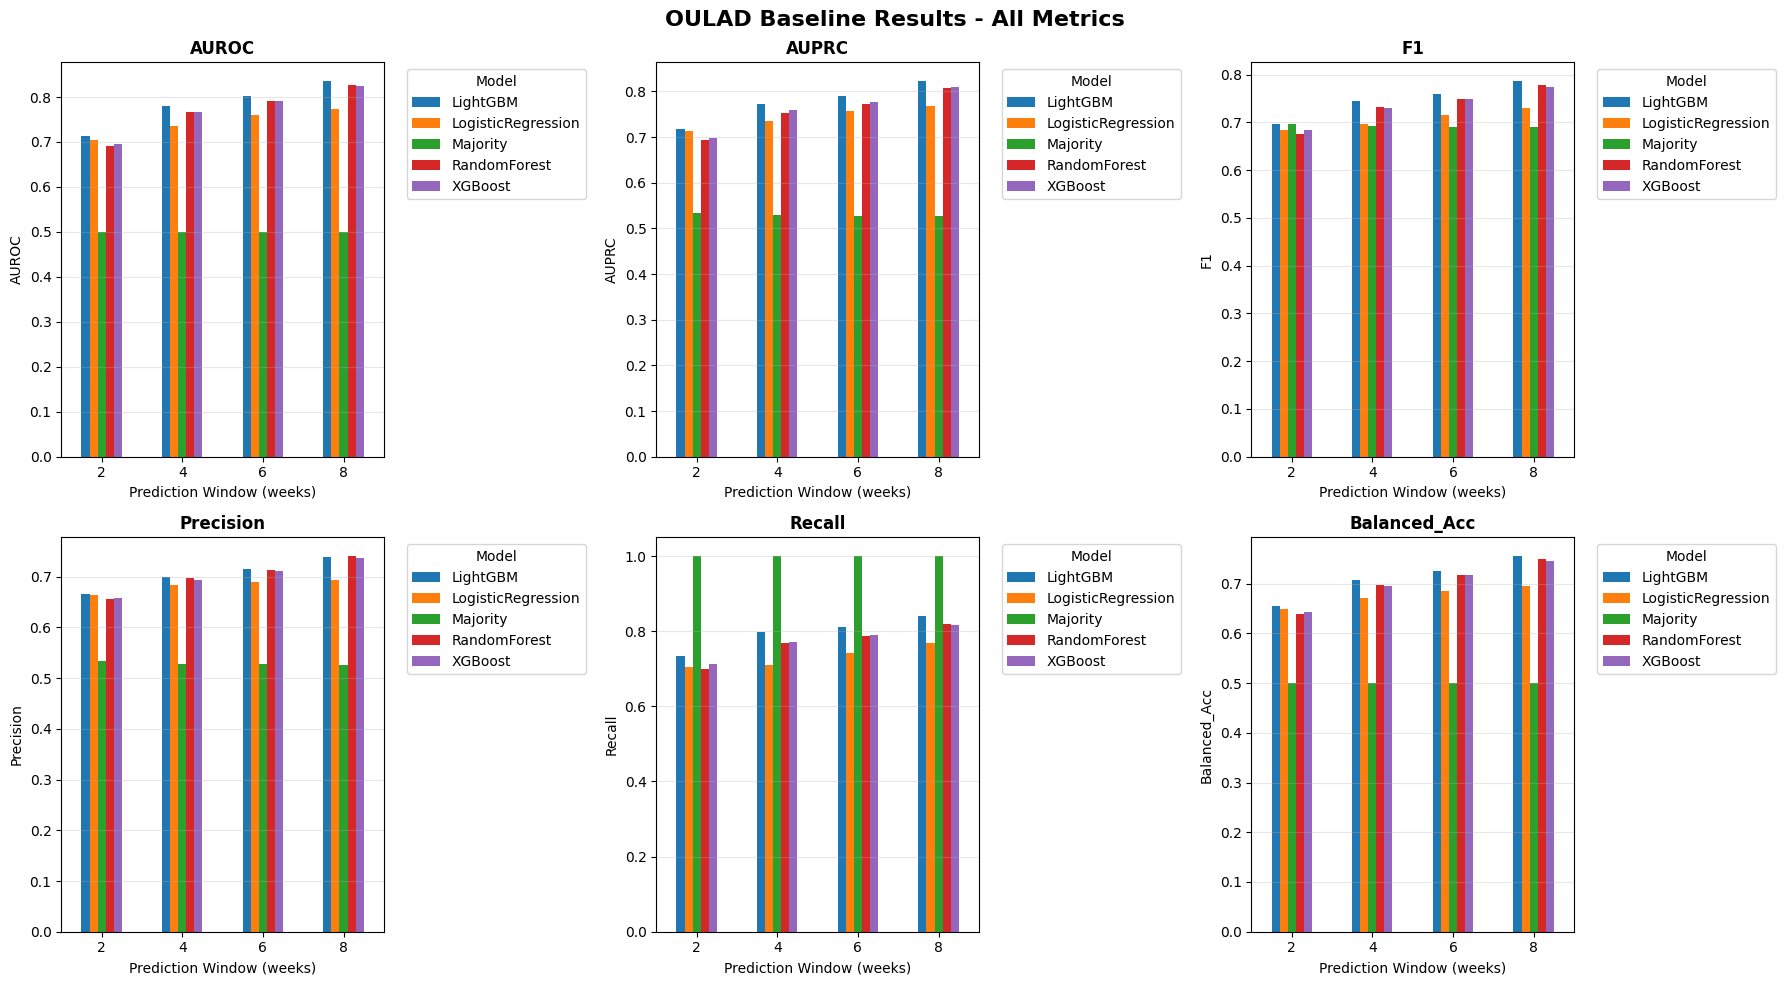

In [26]:
# ============================================================================
# 7. MAIN EXECUTION
# ============================================================================

"""Main execution function"""
print("=" * 80)
print("OULAD BASELINE ANALYSIS - ENHANCED VERSION")
print("=" * 80)

# Load data
student_info, student_vle, student_assess, assessments = load_oulad_data()

# Create datasets
datasets = create_datasets(student_info, student_vle, student_assess, assessments)

# Run baseline evaluation
results_df = run_baseline_evaluation(datasets)

# Save results
results_df.to_csv("baseline_results_detailed.csv", index=False)
print("\n✓ Detailed results saved to: baseline_results_detailed.csv")

# Create and save formatted table
results_table = create_results_table(results_df)
results_table.to_csv("baseline_results_table.csv", index=False)
print("✓ Results table saved to: baseline_results_table.csv")

# Print summary
print("\n" + "=" * 80)
print("BASELINE RESULTS SUMMARY")
print("=" * 80)
print(results_table.to_string(index=False))

# Create visualization
fig = plot_baseline_results(results_df)
fig.savefig("baseline_results_plot.png", dpi=300, bbox_inches="tight")
print("\n✓ Visualization saved to: baseline_results_plot.png")

Baseline validation

In [28]:
results_df.head(10)

,Week,Model,Features,N_features,AUROC_mean,AUROC_std,AUPRC_mean,AUPRC_std,F1_mean,F1_std,Precision_mean,Precision_std,Recall_mean,Recall_std,Balanced_Acc_mean,Balanced_Acc_std
0,2,Majority,All_features,44,0.500000,0.000000,0.533706,0.000071,0.695969,0.000060,0.533706,0.000071,1.000000,0.000000,0.500000,0.000000
1,2,LogisticRegression,VLE_only,3,0.660019,0.007172,0.674729,0.008081,0.623155,0.005589,0.650652,0.006550,0.597919,0.006349,0.615211,0.005996
2,2,LogisticRegression,Assessment_only,3,0.510634,0.001849,0.542861,0.001233,0.695824,0.000695,0.534605,0.000366,0.996263,0.001915,0.501797,0.000854
3,2,LogisticRegression,VLE+Assessment,6,0.665098,0.006902,0.678583,0.008465,0.623573,0.006164,0.654458,0.003962,0.595517,0.008993,0.617829,0.004441
4,2,LogisticRegression,All_features,44,0.705147,0.003456,0.713541,0.006909,0.683589,0.005757,0.663766,0.005109,0.704678,0.008561,0.648047,0.005662
5,2,RandomForest,VLE_only,3,0.607169,0.007343,0.619722,0.007649,0.624341,0.005308,0.603789,0.005278,0.646361,0.006396,0.580435,0.006005
6,2,RandomForest,Assessment_only,3,0.508730,0.001981,0.540721,0.001291,0.694555,0.000921,0.534166,0.000433,0.992594,0.002545,0.500917,0.000964
7,2,RandomForest,VLE+Assessment,6,0.614217,0.006927,0.625485,0.006897,0.624973,0.004365,0.606604,0.003887,0.644492,0.005086,0.583052,0.004566
8,2,RandomForest,All_features,44,0.691610,0.004476,0.693653,0.005740,0.676618,0.005036,0.655508,0.005232,0.699206,0.008572,0.639278,0.005264
9,2,XGBoost,VLE_only,3,0.634030,0.006355,0.650568,0.007898,0.639848,0.004822,0.615044,0.004385,0.666779,0.007553,0.594539,0.004904


=== BASELINE VERIFICATION ===
Results rows: 68
All required columns present
All prediction windows present

Models found: <StringArray>
['Majority', 'LogisticRegression', 'RandomForest', 'XGBoost', 'LightGBM']
Length: 5, dtype: str

Checking metric ranges...
Metrics are within valid range (0–1)
No suspicious perfect scores

=== SUMMARY STATISTICS ===


,Week,N_features,AUROC_mean,AUROC_std,AUPRC_mean,AUPRC_std,F1_mean,F1_std,Precision_mean,Precision_std,Recall_mean,Recall_std,Balanced_Acc_mean,Balanced_Acc_std
count,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000
mean,5.000000,15.764706,0.693606,0.005517,0.695940,0.006451,0.694831,0.004466,0.655153,0.005143,0.754991,0.006108,0.643719,0.005124
std,2.252693,18.400290,0.087472,0.002482,0.075208,0.002919,0.043509,0.002242,0.056896,0.002511,0.110408,0.003377,0.067258,0.002530
min,2.000000,3.000000,0.500000,0.000000,0.526768,0.000040,0.611349,0.000034,0.526768,0.000040,0.562038,0.000000,0.500000,0.000000
25%,3.500000,3.000000,0.658855,0.004176,0.670652,0.004955,0.663271,0.003038,0.630572,0.003798,0.693307,0.004076,0.613975,0.003607
50%,5.000000,6.000000,0.702480,0.005451,0.701717,0.006516,0.694785,0.004483,0.662626,0.005214,0.738327,0.005971,0.648252,0.005298
75%,6.500000,44.000000,0.759490,0.007614,0.754403,0.008181,0.730068,0.006256,0.694260,0.007031,0.791440,0.008286,0.692149,0.007088
max,8.000000,44.000000,0.835335,0.010130,0.822491,0.013719,0.786582,0.008189,0.740655,0.009546,1.000000,0.016034,0.755366,0.009852



 Baseline verification complete


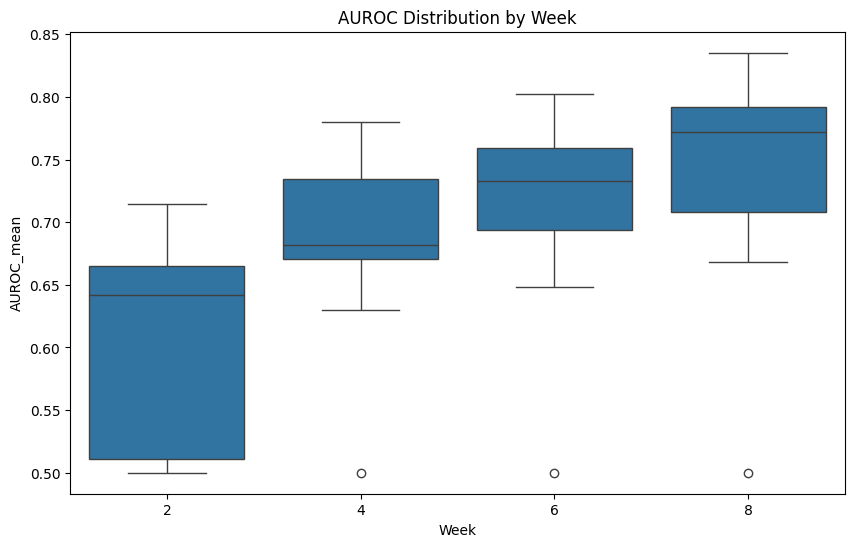

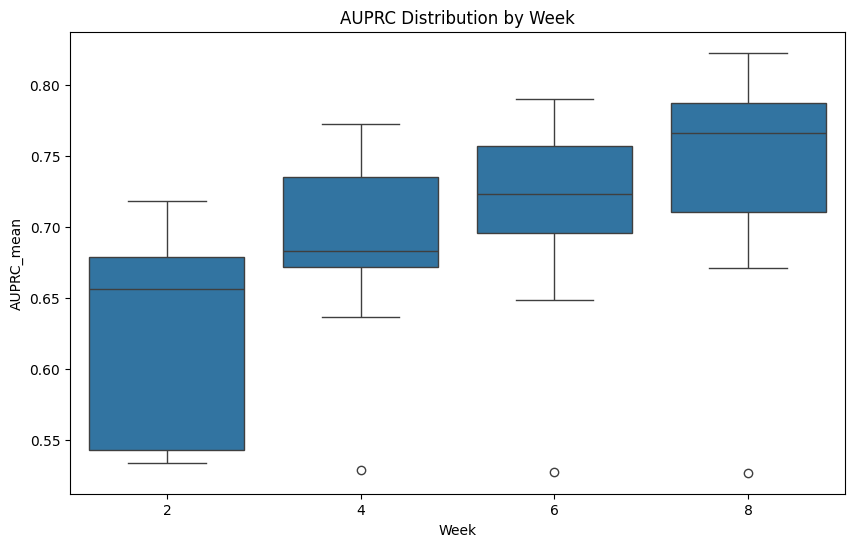

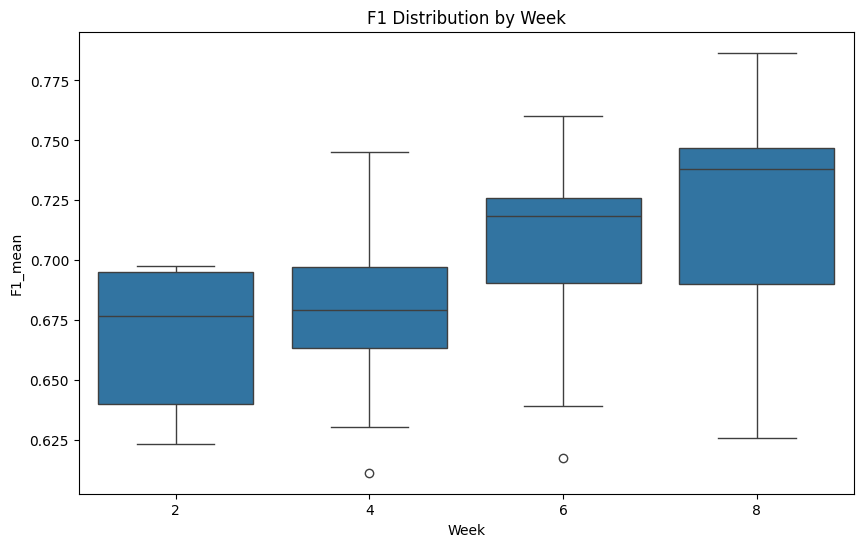

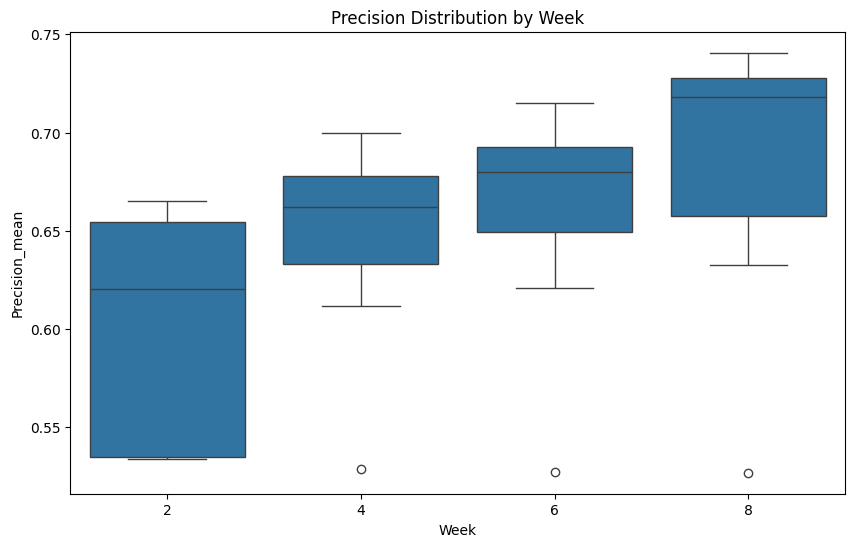

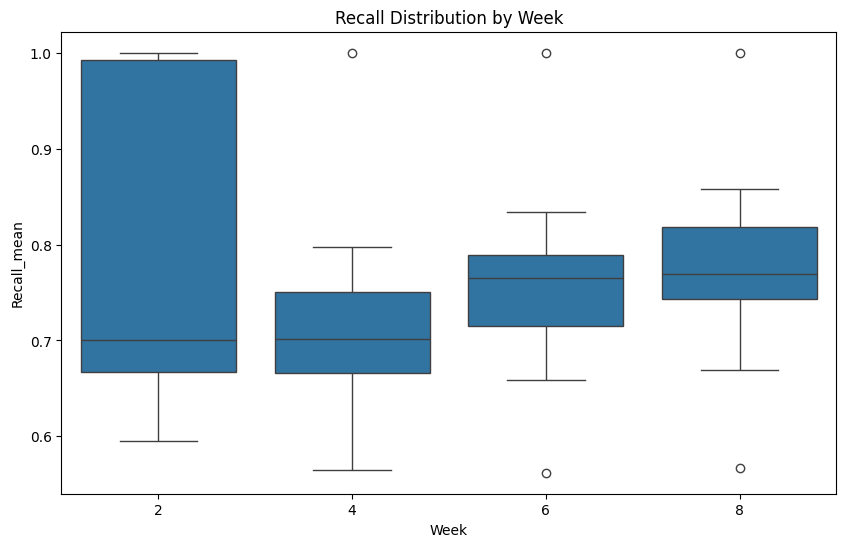

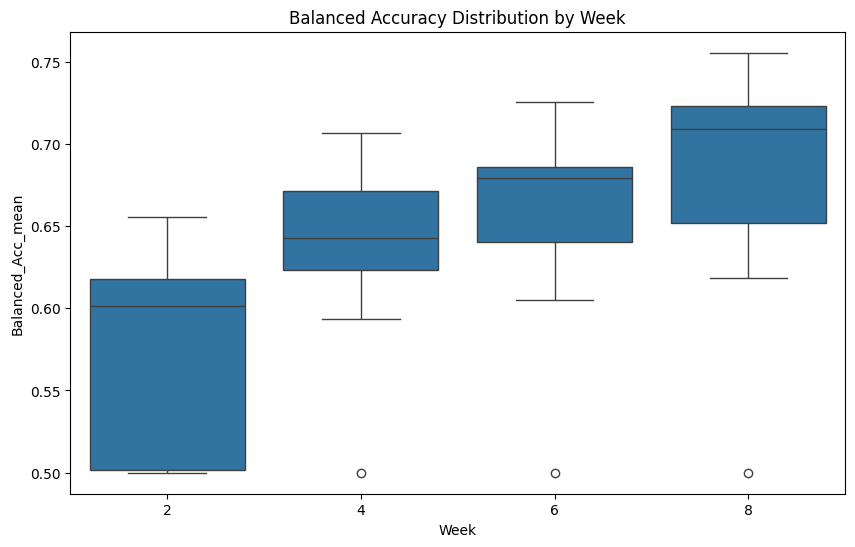

In [38]:
def verify_baseline_results(results_df):

    print("=== BASELINE VERIFICATION ===")

    #  1. Check existence
    if results_df is None:
        print("Results_df is None")
        return
    
    #  2. Check empty
    if results_df.empty:
        print("Results_df is empty")
        return
    else:
        print(f"Results rows: {len(results_df)}")

    #  3. Required columns
    required_cols = ['Week', 'Model', 'AUROC_mean', 'AUPRC_mean', 'F1_mean', 'Precision_mean', 'Recall_mean', 'Balanced_Acc_mean']
    
    missing_cols = [c for c in required_cols if c not in results_df.columns]
    
    if missing_cols:
        print(f"Missing columns: {missing_cols}")
        return
    else:
        print("All required columns present")

    # 4. Check windows coverage
    expected_windows = {2, 4, 6, 8}
    actual_windows = set(results_df['Week'].unique())
    
    if not expected_windows.issubset(actual_windows):
        print(f"Missing weeks: {expected_windows - actual_windows}")
    else:
        print("All prediction windows present")

    # 5. Check models coverage
    print("\nModels found:", results_df['Model'].unique())

    # 6. Check metric ranges
    print("\nChecking metric ranges...")
    
    for col in ['AUROC_mean', 'AUPRC_mean', 'F1_mean', 'Precision_mean', 'Recall_mean', 'Balanced_Acc_mean']:
        if results_df[col].isnull().any():
            print(f"NaNs found in {col}")
        
        if ((results_df[col] < 0) | (results_df[col] > 1)).any():
            print(f"Invalid values in {col}")
    
    print("Metrics are within valid range (0–1)")

    # 7. Detect suspicious perfect scores
    perfect = (results_df[['AUROC_mean','AUPRC_mean','F1_mean']]==1.0).all(axis=1)
    
    if perfect.any():
        print("Perfect scores detected — possible leakage")
    else:
        print("No suspicious perfect scores")

    # 8. Summary
    print("\n=== SUMMARY STATISTICS ===")
    display(results_df.describe())

    print("\n Baseline verification complete")

source_df = globals().get('results_df', globals().get('Results_df'))

Results_df = (
    source_df.copy()
    if isinstance(source_df, pd.DataFrame)
    else pd.DataFrame(columns=['Week', 'Model', 'AUROC_mean', 'AUPRC_mean', 'F1_mean', 'Precision_mean', 'Recall_mean', 'Balanced_Acc_mean'])
)
verify_baseline_results(Results_df)

plt.figure(figsize=(10,6))
plot_df = Results_df.copy()

if (not plot_df.empty) and {'Week', 'AUROC_mean'}.issubset(plot_df.columns):
    sns.boxplot(data=plot_df, x='Week', y='AUROC_mean')
else:
    plt.text(0.5, 0.5, "No AUROC data available to plot", ha='center', va='center')
    plt.axis('off')
plt.title("AUROC Distribution by Week")
plt.show()

plt.figure(figsize=(10,6))
plot_df = Results_df.copy()

if (not plot_df.empty) and {'Week', 'AUPRC_mean'}.issubset(plot_df.columns):
    sns.boxplot(data=plot_df, x='Week', y='AUPRC_mean')
else:
    plt.text(0.5, 0.5, "No AUPRC data available to plot", ha='center', va='center')
    plt.axis('off')
plt.title("AUPRC Distribution by Week")
plt.show()

plt.figure(figsize=(10,6))
plot_df = Results_df.copy()

if (not plot_df.empty) and {'Week', 'F1_mean'}.issubset(plot_df.columns):
    sns.boxplot(data=plot_df, x='Week', y='F1_mean')
else:
    plt.text(0.5, 0.5, "No F1 data available to plot", ha='center', va='center')
    plt.axis('off')
plt.title("F1 Distribution by Week")
plt.show()

plt.figure(figsize=(10,6))
plot_df = Results_df.copy()

if (not plot_df.empty) and {'Week', 'Precision_mean'}.issubset(plot_df.columns):
    sns.boxplot(data=plot_df, x='Week', y='Precision_mean')
else:
    plt.text(0.5, 0.5, "No Precision data available to plot", ha='center', va='center')
    plt.axis('off')
plt.title("Precision Distribution by Week")
plt.show()

plt.figure(figsize=(10,6))
plot_df = Results_df.copy()

if (not plot_df.empty) and {'Week', 'Recall_mean'}.issubset(plot_df.columns):
    sns.boxplot(data=plot_df, x='Week', y='Recall_mean')
else:
    plt.text(0.5, 0.5, "No Recall data available to plot", ha='center', va='center')
    plt.axis('off')
plt.title("Recall Distribution by Week")
plt.show()

plt.figure(figsize=(10,6))
plot_df = Results_df.copy()

if (not plot_df.empty) and {'Week', 'Balanced_Acc_mean'}.issubset(plot_df.columns):
    sns.boxplot(data=plot_df, x='Week', y='Balanced_Acc_mean')
else:
    plt.text(0.5, 0.5, "No Balanced Accuracy data available to plot", ha='center', va='center')
    plt.axis('off')
plt.title("Balanced Accuracy Distribution by Week")
plt.show()